# Módulo 6 — Proyecciones locales y evidencia narrativa

**Curso complementario · puremacro**

### Objetivos de aprendizaje
Al terminar esta lección podrás:
1. Estimar una **función de impulso-respuesta (IRF)** con **proyecciones locales (LP)**
   y errores estándar **HAC**, y contrastarla con un **SVAR** recursivo.
2. Enunciar el resultado de **Plagborg-Møller y Wolf (2021)**: LP y VAR estiman *la
   misma* IRF poblacional; coinciden en horizontes cortos y **divergen** en los largos.
3. Identificar un choque de política con **evidencia narrativa** (Romer-Romer) y estimar
   el **multiplicador impositivo** por **proxy-IV** (variable instrumental externa):
   el % que se mueve el PIB ante un alza impositiva legislada de **1% del PIB**.
4. Diagnosticar **instrumentos débiles** con la **F efectiva** de primera etapa
   (Montiel Olea y Pflueger 2013).

Todo corre en Python puro sobre tu **instalación local** de `puremacro`
(`pip install puremacro`): sin conexión y sin costo.

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib
try:  # bajo Jupyter/ipykernel: conserva el backend inline (captura figuras)
    get_ipython()
except NameError:
    matplotlib.use("Agg")  # script plano / CLI: backend no interactivo
import matplotlib.pyplot as plt
_cwd = pathlib.Path.cwd()
_nb = _cwd if (_cwd / "_nbstyle.py").exists() else _cwd.parent
sys.path.insert(0, str(_nb)); sys.path.insert(0, str(_nb / "course"))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor
DATA = (_nb / "course" / "data")

## 1. Dos formas de estimar una IRF

Una **función de impulso-respuesta** traza cómo reacciona una variable $y_{t+h}$ ante un
choque en $t$, horizonte por horizonte $h = 0, 1, 2, \dots$

- **SVAR:** ajustas *un* VAR y **extrapolas** la IRF con su estructura paramétrica
  (potencias de la matriz de coeficientes). Eficiente si el VAR está bien especificado.
- **Proyección local (Jordà 2005):** para *cada* horizonte corres una regresión separada
  $y_{t+h}-y_{t-1}=\alpha_h+\beta_h\,x_t+\text{(rezagos)}+\varepsilon_{t,h}$.
  El coeficiente $\beta_h$ **es** la IRF en $h$. Flexible y robusta a mala especificación,
  pero más ruidosa.

### Plagborg-Møller y Wolf (2021)
Demuestran que, con el mismo conjunto de información, **LP y VAR estiman la misma IRF
poblacional** — un VAR es una LP cuya respuesta está restringida a una forma paramétrica.
En muestras finitas con un VAR de orden finito:
- **coinciden en horizontes cortos** (en $h=0$ ambas son la misma proyección contemporánea);
- **divergen en horizontes largos**: el VAR extrapola una curva suave; la LP, sin restringir,
  sigue la trayectoria muestral (más ruido, menos sesgo por mala especificación).

En `puremacro`: `lp.lp_hac` usa **ancho de banda HAC $= h+1$** (recomendación de PMW 2021).

In [2]:
from puremacro.lp import lp_hac                       # LP con errores estándar HAC (Newey-West)
from puremacro.var.identify import cholesky as cholesky_svar   # SVAR recursivo, bandas bootstrap
                                                               # (el mazo lo llama identify.cholesky_svar)

# Sistema bivariado simulado (choque x -> respuesta y). SIMULADO con semilla fija: no hay un
# par (choque, respuesta) canónico en el bundle para ilustrar la equivalencia, y aquí nos
# interesa justamente conocer la IRF POBLACIONAL para saber quién se equivoca.
rng = np.random.default_rng(424242)
T = 300
rho_x, rho_y, gamma = 0.6, 0.5, 0.8
x = np.zeros(T)
for t in range(1, T):
    x[t] = rho_x * x[t - 1] + 0.7 * rng.standard_normal()          # x sigue un AR(1) persistente
y = np.zeros(T)
for t in range(1, T):
    y[t] = rho_y * y[t - 1] + gamma * x[t] + 0.5 * rng.standard_normal()   # y responde al choque de x
df_sim = pd.DataFrame({"x": x, "y": y})

# El PGD es EXACTAMENTE un VAR(1) bivariado con x ordenado primero, así que la IRF poblacional
# se conoce en forma cerrada: respuesta de y en h a una innovación unitaria de x.
H = 16
irf_pop = np.array([sum(gamma * rho_y ** (h - j) * rho_x ** j for j in range(h + 1))
                    for h in range(H + 1)])

lp = lp_hac(df_sim, y="y", x="x", horizons=range(0, H + 1), n_lags=4)   # cols: h, beta, se, t, lo, hi
sv = cholesky_svar(df_sim[["x", "y"]].values, p=4, horizon=H, n_boot=200, ci=0.9, seed=0)

# La IRF LP es la respuesta de y por unidad de x_t. Escalamos el SVAR (choque de 1 d.e.
# ordenado con x primero) al mismo impacto unitario sobre x para comparar en la misma escala.
irf_y = sv.irf_point[:, 1, 0]          # respuesta de y (var 1) al choque de x (col 0)
irf_x0 = sv.irf_point[0, 0, 0]         # impacto contemporáneo sobre x
svar_beta = irf_y / irf_x0
lp_beta = lp.set_index("h")["beta"].to_numpy()

# El contraste correcto NO es "h=0 contra h=H" (en h=H ambas curvas pueden haber vuelto a
# cruzarse cerca de cero): es el impacto contra la BRECHA MÁXIMA sobre todos los horizontes.
gaps = np.abs(lp_beta - svar_beta)
gap_corto = gaps[0]                                  # h=0: deben coincidir casi exacto
h_max = int(np.argmax(gaps)); gap_max = gaps[h_max]  # horizonte de máxima divergencia
print(f"h=0    LP={lp_beta[0]:+.3f}  SVAR={svar_beta[0]:+.3f}  poblacional={irf_pop[0]:+.3f}"
      f"   |dif LP-SVAR|={gap_corto:.4f}")
print(f"h={h_max:<4d} LP={lp_beta[h_max]:+.3f}  SVAR={svar_beta[h_max]:+.3f}  "
      f"poblacional={irf_pop[h_max]:+.3f}   |dif LP-SVAR|={gap_max:.4f}  <- brecha máxima")
print(f"error absoluto medio frente a la IRF poblacional:  "
      f"LP={np.abs(lp_beta - irf_pop).mean():.3f}   SVAR={np.abs(svar_beta - irf_pop).mean():.3f}")
assert gap_corto < 1e-3    # coinciden en el impacto (PMW 2021)
assert gap_max > 0.1       # y divergen materialmente en algún horizonte intermedio/largo
assert h_max > 4           # esa divergencia no ocurre en los horizontes cortos

h=0    LP=+0.732  SVAR=+0.732  poblacional=+0.800   |dif LP-SVAR|=0.0000
h=10   LP=-0.261  SVAR=+0.013  poblacional=+0.025   |dif LP-SVAR|=0.2743  <- brecha máxima
error absoluto medio frente a la IRF poblacional:  LP=0.121   SVAR=0.023


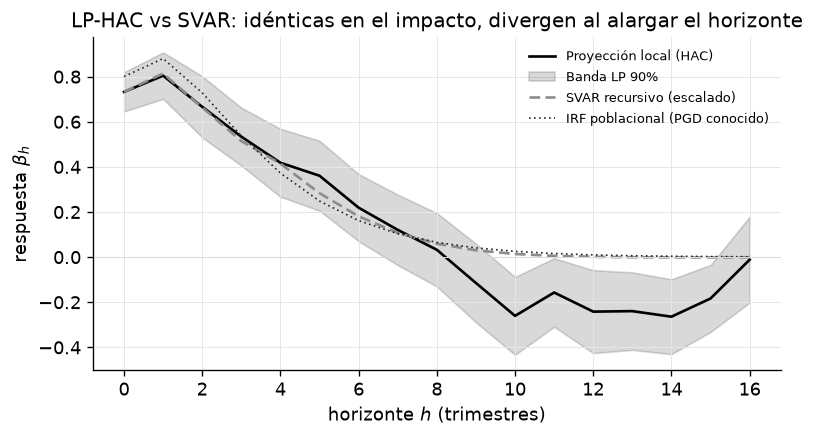

In [3]:
cols = _nbstyle.palette(2)
hs = np.arange(H + 1)
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.plot(hs, lp_beta, color=cols[0], lw=1.6, label="Proyección local (HAC)")
ax.fill_between(hs, lp.set_index("h")["lo"], lp.set_index("h")["hi"],
                color=cols[0], alpha=0.15, label="Banda LP 90%")
ax.plot(hs, svar_beta, color="0.55", lw=1.6, ls=(0, (4, 2)), label="SVAR recursivo (escalado)")
ax.plot(hs, irf_pop, color="0.15", lw=1.0, ls=(0, (1, 2)), label="IRF poblacional (PGD conocido)")
ax.axhline(0, color="0.85", lw=0.6)
ax.set_xlabel("horizonte $h$ (trimestres)"); ax.set_ylabel(r"respuesta $\beta_h$")
ax.set_title("LP-HAC vs SVAR: idénticas en el impacto, divergen al alargar el horizonte")
ax.legend(loc="upper right", frameon=False, fontsize=8)
plt.show()

### Cómo leer la figura
En $h=0$ ambas son **idénticas hasta el error de redondeo** (`|dif| = 0.0000`): con los
mismos cuatro rezagos, la LP en $h=0$ *es* la misma regresión que el impacto contemporáneo
del SVAR recursivo. En horizontes cortos casi se solapan. Al alargar el horizonte, el SVAR
**decae suave** hacia cero (impone la dinámica del VAR), mientras la LP **oscila** siguiendo
la muestra: la brecha máxima que imprime el diagnóstico aparece en torno a $h=10$ y vale
unas 0.27 unidades de respuesta, frente a cero (hasta el redondeo) en el impacto.

Ojo con un espejismo: en $h=16$ las dos curvas vuelven a estar cerca de cero y la diferencia
es pequeña otra vez. Por eso el diagnóstico compara el impacto contra la **brecha máxima**
sobre todos los horizontes, no contra el último.

Aquí sabemos quién acierta, porque el PGD es exactamente un VAR(1) con $x$ ordenado primero:
la línea punteada oscura es la **IRF poblacional**. El SVAR está bien especificado y su
error medio frente a esa verdad es mucho menor que el de la LP. Ese es el mensaje de PMW
(2021) con todas sus letras: **misma IRF poblacional**, distinto sesgo/varianza en muestra
finita. Si el VAR está bien especificado —como en esta simulación— su IRF larga es más
precisa; si dudas de la especificación (el caso habitual con datos reales, donde nadie te
enseña el PGD), la LP es la apuesta segura.

## 2. Identificación narrativa: el multiplicador impositivo

¿Cuánto cae el PIB cuando suben los impuestos? El problema es de **endogeneidad**: la
recaudación observada también reacciona al ciclo (se recauda más cuando la economía crece).
La **identificación narrativa** (Romer y Romer 2010) lee documentos legislativos para aislar
los cambios impositivos **exógenos** —motivados por ideología o déficit heredado, no por
la coyuntura— y los usa como regresor o como **instrumento** (proxy-IV).

**Ficha de los datos.** `tax14_narrative_tax_shocks.csv` (EE. UU., trimestral,
1945Q1–2007Q4, 252 obs.) viene congelado en el bundle; su origen es el archivo fiscal
público de Valerie Ramey (*Handbook of Macroeconomics* 2016, hoja `homtaxdat`). Las tres
series están en **% del PIB** y con el signo **positivo = alza impositiva legislada**:

| columna | contenido | fuente original |
|---|---|---|
| `rr_exog` | cambios impositivos **exógenos** de Romer-Romer (déficit heredado / largo plazo) | `EXOGENRRATIO` |
| `mtr_u`   | cambios legislados **no anticipados** (Mertens-Ravn) | `TAXU` |
| `mtr_a`   | cambios legislados **anticipados** (anunciados antes de entrar en vigor) | `taxnews` |

Que las tres estén en % del PIB es lo que hace que los coeficientes de abajo se lean
directamente como **multiplicador impositivo**: % de respuesta del PIB por cada alza
impositiva de 1% del PIB. El PIB real es `GDPC1` (FRED); como esa serie arranca en 1947Q1
y tomamos una diferencia, la muestra fusionada empieza en **1947Q2**. En esta lección
`mtr_a` sólo se documenta: no entra en ninguna regresión.

In [4]:
from puremacro.lp import lp_iv                         # LP con variable instrumental (Stock-Watson 2018; PMW 2021)

tax = pd.read_csv(DATA / "tax14_narrative_tax_shocks.csv")            # del bundle (offline)
gdp = pd.read_csv(DATA / "GDPC1.csv")                                 # PIB real de EE. UU. (FRED)
gdp["date"] = pd.PeriodIndex(pd.to_datetime(gdp["observation_date"]), freq="Q").astype(str)
gdp["y"] = 100.0 * np.log(gdp["GDPC1"])               # PIB real en log-puntos (×100 = %)
gdp["dgdp"] = gdp["y"].diff()                         # crecimiento trimestral del PIB (%)

df = tax.merge(gdp[["date", "y", "dgdp"]], on="date", how="inner").dropna().reset_index(drop=True)
print(f"muestra fusionada: {len(df)} trimestres, {df['date'].iloc[0]}–{df['date'].iloc[-1]}")

# Dos de las "tres vías" del mazo, sobre exactamente los mismos datos y los mismos 4 rezagos:
#   (a) LP directa (OLS): el PIB sobre la serie narrativa mtr_u, sin instrumentar.
#   (b) LP-IV (proxy-IV): mtr_u instrumentado con rr_exog. Ambas series miden las MISMAS
#       leyes fiscales, leídas por equipos distintos; el error de medida de una es en buena
#       parte independiente del de la otra, y eso es lo que la IV explota.
Htax = 12
ols = lp_hac(df, y="y", x="mtr_u", horizons=range(0, Htax + 1), n_lags=4).set_index("h")
iv = lp_iv(df, y="y", x="mtr_u", z="rr_exog", horizons=range(0, Htax + 1), n_lags=4).set_index("h")

tab = pd.DataFrame({"beta_OLS": ols["beta"], "beta_IV": iv["beta"],
                    "se_IV": iv["se"], "F_1a_etapa": iv["first_stage_f"]})
print(tab.round(3).to_string())
h_pico = int(iv["beta"].idxmin())
print(f"\npico de la LP-IV: h={h_pico}  beta={iv['beta'].loc[h_pico]:+.2f} % del PIB"
      f"   (OLS en el mismo h: {ols['beta'].loc[h_pico]:+.2f})")
print(f"razón IV/OLS en el pico = {iv['beta'].loc[h_pico] / ols['beta'].loc[h_pico]:.1f}x"
      f"   <- atenuación por error de medida en la serie narrativa")
assert iv["beta"].min() < 0        # un alza impositiva contrae el PIB (multiplicador negativo)
assert abs(iv["beta"].loc[h_pico]) > abs(ols["beta"].loc[h_pico])   # la IV corrige hacia arriba

muestra fusionada: 243 trimestres, 1947Q2–2007Q4


    beta_OLS  beta_IV  se_IV  F_1a_etapa
h                                       
0     -0.274   -0.142  0.219      16.110
1     -0.280   -0.332  0.347      16.350
2     -0.195   -0.088  0.485      16.666
3     -0.248   -0.210  0.695      15.472
4     -0.240   -0.344  0.848      14.784
5     -0.340   -0.524  0.889      14.740
6     -0.160   -0.541  1.105      14.755
7     -0.493   -1.148  1.007      14.495
8     -0.477   -1.321  0.896      14.286
9     -0.617   -1.561  0.767      14.129
10    -0.673   -1.685  0.761      13.996
11    -0.416   -1.369  0.732      13.836
12    -0.267   -1.198  0.695      13.479

pico de la LP-IV: h=10  beta=-1.68 % del PIB   (OLS en el mismo h: -0.67)
razón IV/OLS en el pico = 2.5x   <- atenuación por error de medida en la serie narrativa


### ¿Instrumento fuerte o débil? La F de primera etapa
La primera etapa proyecta el regresor endógeno (`mtr_u`) sobre el instrumento narrativo
(`rr_exog`). Si esa relación es **débil**, la 2SLS se sesga y las bandas engañan. El
diagnóstico moderno es la **F efectiva de Montiel Olea y Pflueger (2013)**, que es robusta
a heterocedasticidad: con $k=1$ instrumento y 2SLS, $F>23.1$ ⇒ *fuerte*; por debajo conviene
**inferencia robusta a IV débil** (Anderson-Rubin, por ejemplo).

Fíjate en el contraste que viene: la correlación simple entre instrumento y regresor es
**alta**, y aun así la F efectiva se queda **por debajo del umbral**. No es una
contradicción. Estas series son casi siempre cero con unos pocos picos legislativos
enormes, así que la relación descansa sobre un puñado de trimestres: la F *usual*, que
supone homocedasticidad, sería altísima, mientras que la F efectiva —que no lo supone—
castiga precisamente esa concentración. Es un buen recordatorio de que la relevancia de un
instrumento no se juzga con un coeficiente de correlación.

In [5]:
from puremacro.inference.weak_iv import olea_pflueger_f
from puremacro.var.identify.proxy import proxy_svar    # proxy-SVAR (Mertens-Ravn 2013 / Stock-Watson 2018)

corr = np.corrcoef(df["rr_exog"], df["mtr_u"])[0, 1]
F_op = olea_pflueger_f(df["mtr_u"].to_numpy(), df["rr_exog"].to_numpy().reshape(-1, 1))
veredicto = "FUERTE" if F_op > 23.1 else "por DEBAJO de 23.1 -> usar inferencia robusta a IV débil"
print(f"corr(rr_exog, mtr_u) = {corr:.2f}   (relevancia aparente del instrumento)")
print(f"F efectiva Montiel Olea-Pflueger = {F_op:.1f}   ->  {veredicto}")

# Ruta alternativa (proxy-SVAR): mismo instrumento, VAR en [impuesto, crecimiento del PIB].
res = proxy_svar(df[["mtr_u", "dgdp"]].to_numpy(), p=4, horizon=Htax,
                 instrument_series=df["rr_exog"].to_numpy(), n_boot=200, ci=0.9, seed=0)
# irf_point[:, 1, 0] es la respuesta de dgdp (crecimiento); la acumulamos para tener el NIVEL
# del PIB, y dividimos por el impacto sobre mtr_u para normalizar a un alza de 1% del PIB
# -> exactamente la misma escala que la beta de la LP-IV, así que son comparables punto a punto.
svar_level = np.cumsum(res.irf_point[:, 1, 0]) / res.irf_point[0, 0, 0]
print(f"F efectiva del proxy-SVAR = {res.first_stage_F:.1f}   (segunda lectura, sobre los residuos del VAR)")
print(f"impacto del choque identificado sobre mtr_u = {res.irf_point[0, 0, 0]:.3f} (% del PIB)")
assert F_op > 0

corr(rr_exog, mtr_u) = 0.71   (relevancia aparente del instrumento)
F efectiva Montiel Olea-Pflueger = 15.6   ->  por DEBAJO de 23.1 -> usar inferencia robusta a IV débil


F efectiva del proxy-SVAR = 15.5   (segunda lectura, sobre los residuos del VAR)
impacto del choque identificado sobre mtr_u = 0.391 (% del PIB)


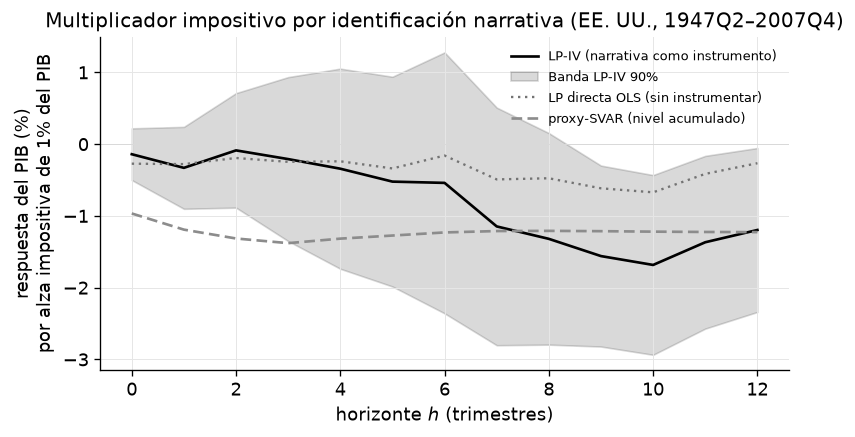

In [6]:
hs = np.arange(Htax + 1)
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.plot(hs, iv["beta"], color=cols[0], lw=1.6, label="LP-IV (narrativa como instrumento)")
ax.fill_between(hs, iv["lo"], iv["hi"], color=cols[0], alpha=0.15, label="Banda LP-IV 90%")
ax.plot(hs, ols["beta"], color=cols[1], lw=1.4, ls=(0, (1, 2)), label="LP directa OLS (sin instrumentar)")
ax.plot(hs, svar_level, color="0.55", lw=1.6, ls=(0, (4, 2)), label="proxy-SVAR (nivel acumulado)")
ax.axhline(0, color="0.85", lw=0.6)
ax.set_xlabel("horizonte $h$ (trimestres)")
ax.set_ylabel("respuesta del PIB (%)\npor alza impositiva de 1% del PIB")
ax.set_title("Multiplicador impositivo por identificación narrativa (EE. UU., 1947Q2–2007Q4)")
ax.legend(loc="upper right", frameon=False, fontsize=8)
plt.show()

### Cómo leer la figura
**Unidades.** Las tres curvas están en la misma escala: % de respuesta del PIB por un alza
impositiva legislada de 1% del PIB. La normalización *no* difiere entre rutas — la LP-IV da
el coeficiente directamente y al proxy-SVAR lo dividimos por su impacto sobre `mtr_u` justo
para dejarlo aquí. Por eso se pueden comparar punto a punto.

**El resultado.** Un alza impositiva exógena **contrae** el PIB: la respuesta es negativa y
se profundiza hasta el pico que imprime el diagnóstico, en torno a $h=10$ (dos años y
medio), y luego se atenúa un poco. LP-IV y proxy-SVAR coinciden en signo y magnitud; el
proxy-SVAR cae antes (es un sistema dinámico, arrastra el impacto contemporáneo) y la LP-IV
tarda más en llegar al fondo.

**La lección de la línea punteada.** La LP directa por OLS sobre `mtr_u` es sistemáticamente
**más plana** que la LP-IV: en el pico, la IV es unas 2.5 veces mayor en valor absoluto. Ese
es el argumento de Mertens y Ravn a favor del proxy: la serie narrativa mide con **error**
las leyes fiscales verdaderas, y el error de medida **atenúa** el coeficiente OLS hacia
cero; instrumentar con una lectura independiente de la misma legislación (`rr_exog`, de
Romer-Romer) corrige esa atenuación. Ojo con el matiz: aquí la IV no está corrigiendo la
prociclicidad de la recaudación —`mtr_u` ya es una serie narrativa, no la recaudación
observada— sino ese error de medida.

**Coherencia con el mazo A5.** La transparencia de "el multiplicador impositivo por tres
vías" sitúa a Romer-Romer en $-2.5$ a $-3$ y a Mertens-Ravn en $-2$ a $-3$. Nuestro pico
($\approx -1.7$) queda algo por debajo, y con razón: aquí corremos un sistema mínimo —PIB y
una sola serie fiscal, cuatro rezagos, sin gasto, sin deuda, sin controles— frente a las
especificaciones más ricas de esos artículos. Mismo signo, misma familia de magnitudes,
menos ambición.

**La banda.** Es ancha, y debe serlo: la F efectiva quedó **por debajo de 23.1**. Con un
instrumento que no es del todo fuerte, la incertidumbre es real y la banda usual del 90%
probablemente aún la subestima (de ahí la pregunta 2).

## 3. Preguntas para pensar
1. En la figura de la sección 1, la LP y el SVAR **coinciden en $h=0$** por construcción.
   ¿Por qué? (Pista: ¿qué regresión es la LP en $h=0$ y qué es el impacto contemporáneo
   del SVAR?) ¿Y por qué el SVAR decae más suave en horizontes largos?
2. En esa misma simulación el SVAR le gana a la LP frente a la IRF poblacional. ¿Es eso un
   argumento general a favor del SVAR? ¿Qué tiene de especial **este** PGD, y qué cambiaría
   si $y$ dependiera también de $x_{t-1}$ de una forma que un VAR(4) no puede capturar?
3. La **F efectiva** salió por debajo de 23.1 pese a una correlación simple alta entre
   instrumento y regresor. ¿Qué le pasa al estimador 2SLS y a las bandas de confianza
   cuando el instrumento es débil? ¿Preferirías reportar la banda usual o una **robusta a
   IV débil** (p. ej., Anderson-Rubin)?
4. La LP-IV da un multiplicador ~2.5 veces mayor (en valor absoluto) que la LP directa por
   OLS sobre la misma serie `mtr_u`. Da dos explicaciones rivales de esa brecha: una que
   favorece a la IV (error de medida en la serie narrativa) y otra que la condena
   (`rr_exog` no es realmente exógeno y la IV está amplificando un sesgo). ¿Qué evidencia
   adicional te haría inclinarte por una u otra?

## 4. Explora con IA
Prueba esto con el tutor sin conexión (o cualquier asistente de IA):
- "Explica en dos frases por qué LP y VAR estiman la misma IRF poblacional (Plagborg-Møller-Wolf 2021)."
- "¿Qué es un instrumento débil y por qué la F de primera etapa importa para el multiplicador impositivo?"

In [7]:
print(tutor("En una frase: ¿por qué una F de primera etapa baja invalida la inferencia estándar de IV?"))

[tutor sin conexión] No hay ningún motor de LLM local disponible en esta instalación (el tutor es opcional). Puedes instalar uno con `pip install puremacro[local-llm]` más un modelo pequeño (por ejemplo vía Ollama o MLX), o bien usar las indicaciones de la sección «Explora con IA» de esta lección con cualquier asistente de IA.
(motivo: el motor local no está disponible)


**Resumen.** Estimamos una IRF de dos maneras —**LP-HAC** y **SVAR** recursivo— sobre un
PGD simulado cuya IRF poblacional conocemos, y vimos el resultado de Plagborg-Møller y Wolf
(2021): misma respuesta poblacional, coincidencia exacta en el impacto y divergencia en los
horizontes largos, donde el VAR bien especificado gana precisión y la LP gana robustez.
Luego identificamos un choque de política con **evidencia narrativa** (Romer-Romer) y
estimamos el **multiplicador impositivo** —% del PIB por alza de 1% del PIB— por tres
rutas: LP directa por OLS, **LP-IV** (`lp_iv`) y **proxy-SVAR** (`proxy_svar`). La brecha
entre OLS e IV es el argumento de atenuación de Mertens y Ravn; la **F efectiva de Montiel
Olea y Pflueger**, por debajo de 23.1, es el recordatorio de que la banda del 90% se lee
con humildad. Todo en `puremacro` (Python puro), sobre tu instalación local.